In [13]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
from folium.plugins import Draw

# Insert repo root directory into notebook path to allow for import with the repo directory
repository_root = Path.cwd().parent.parent.resolve()
sys.path.insert(0, str(repository_root))

from land_cover_change.config.config import resolved_config
from land_cover_change.data_access.vector import (
    load_vector_data,
    save_shapefile,
)
from land_cover_change.services.aoi import (
    normalize_aoi,
    select_administrative_area,
)

In [14]:
# Resolve configured input and output paths.
base_boundary_path = Path(resolved_config.dataset.raw_dataset.base_data)
raw_aoi_path = Path(resolved_config.dataset.raw_dataset.aoi_geojson)
processed_aoi_path = Path(
    resolved_config.dataset.processed_dataset.aoi_shapefile
)

In [15]:
# Load and validate the Nigeria administrative-boundary dataset.
administrative_boundaries = load_vector_data(base_boundary_path)
administrative_boundaries.head(2)

,globalid,uniq_id,timestamp,editor,wardname,wardcode,lganame,lgacode,statename,statecode,amapcode,status,source,urban,geometry
0,564c8211-f688-4091-b45e-a2862ddcfb54,499246,2020-08-31,najib.adam,Ikuru,RVSNDN06,Andoni,33005,Rivers,RI,NIE RVS NDN,Operational Placeholder,INEC,No,"POLYGON ((7.39065 4.43648, 7.38503 4.4791, 7.3..."
1,a3a0fa0f-b22c-4085-9bdb-1e1c3473d79a,499247,2019-03-16,oluseye.abraham,Aktward 17,RVSABM17,Akuku Toru,33004,Rivers,RI,NIE RVS ABM,Operational Placeholder,INEC,No,"POLYGON ((6.71866 4.61093, 6.71477 4.6205, 6.7..."


In [16]:
# Display the datatypes of the geopandas dataframe
administrative_boundaries.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 9410 entries, 0 to 9409
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   globalid   9410 non-null   str           
 1   uniq_id    9410 non-null   int64         
 2   timestamp  9410 non-null   datetime64[ms]
 3   editor     9410 non-null   str           
 4   wardname   9410 non-null   str           
 5   wardcode   9410 non-null   str           
 6   lganame    9410 non-null   str           
 7   lgacode    9410 non-null   str           
 8   statename  9410 non-null   str           
 9   statecode  9410 non-null   str           
 10  amapcode   7951 non-null   str           
 11  status     9410 non-null   str           
 12  source     9410 non-null   str           
 13  urban      9410 non-null   str           
 14  geometry   9308 non-null   geometry      
dtypes: datetime64[ms](1), geometry(1), int64(1), str(12)
memory usage: 2.2 MB


In [17]:
# Select the administrative area used as context for drawing the AOI.
ward_boundaries = select_administrative_area(
    administrative_boundaries,
    ward_name="Umagbae South",
    state_name="Edo",
)

# Display the selected ward.
ward_boundaries

,globalid,uniq_id,timestamp,editor,wardname,wardcode,lganame,lgacode,statename,statecode,amapcode,status,source,urban,geometry
4380,1f46a45d-e349-4e24-afa1-fab7c1568f60,497240,2019-03-16,oluseye.abraham,Umagbae South,EDSEHR03,Uhunmwonde,12018,Edo,ED,NIE EDS EHR,Operational Placeholder,INEC,No,"POLYGON ((5.76567 6.47742, 5.77081 6.46647, 5...."


In [18]:
# Inspect the selected ward.
ward_boundaries.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 4380 to 4380
Data columns (total 15 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   globalid   1 non-null      str           
 1   uniq_id    1 non-null      int64         
 2   timestamp  1 non-null      datetime64[ms]
 3   editor     1 non-null      str           
 4   wardname   1 non-null      str           
 5   wardcode   1 non-null      str           
 6   lganame    1 non-null      str           
 7   lgacode    1 non-null      str           
 8   statename  1 non-null      str           
 9   statecode  1 non-null      str           
 10  amapcode   1 non-null      str           
 11  status     1 non-null      str           
 12  source     1 non-null      str           
 13  urban      1 non-null      str           
 14  geometry   1 non-null      geometry      
dtypes: datetime64[ms](1), geometry(1), int64(1), str(12)
memory usage: 396.0 bytes


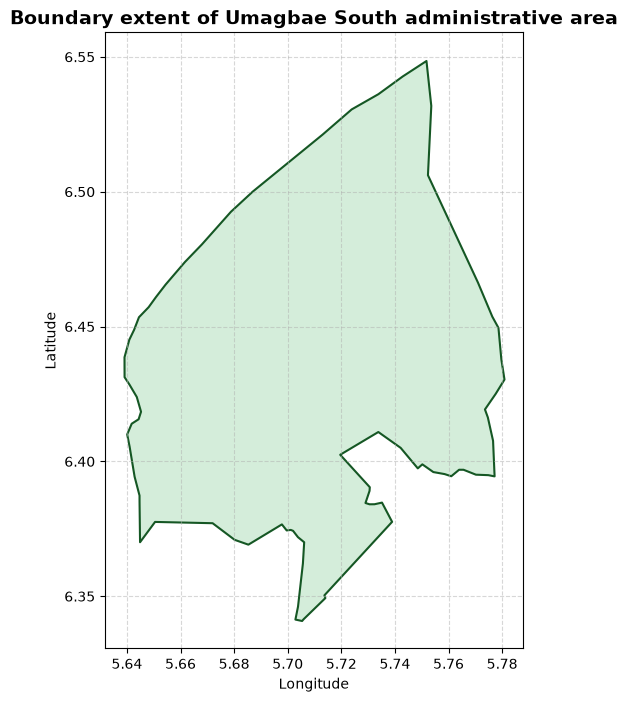

In [19]:
# Plot the Umagbae South administrative boundary.
fig, ax = plt.subplots(figsize=(8, 8))

ward_boundaries.plot(
    ax=ax,
    color="#D4EDDA",
    edgecolor="#155724",
    linewidth=1.5,
)

ax.set_title(
    "Boundary extent of Umagbae South administrative area",
    fontsize=14,
    fontweight="bold",
)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [20]:
# Display Umagbae South over OpenStreetMap and enable polygon drawing.

ward_boundaries_web = ward_boundaries.to_crs("EPSG:4326")

umagbae_south_interactive_webmap = ward_boundaries_web.explore(
    tiles="OpenStreetMap",
    name="Umagbae South boundary",
    tooltip=["wardname", "lganame", "statename"],  # type: ignore
    tooltip_kwds={
        "aliases": ["Ward", "Local government area", "State"]
    },
    style_kwds={
        "fillColor": "transparent",
        "fillOpacity": 0.6,
        "color": "#D35400",
        "weight": 1.5,
    },
    highlight_kwds={
        "fillColor": "transparent",
        "fillOpacity": 0.8,
        "color": "#D35400",
        "weight": 3,
    },
)

# NOTE: Only uncomment if you there is a need to change previously drawn shapefile
# Add polygon drawing and GeoJSON export controls.
# Draw(
#     export=True,
#     filename="custom_aoi.geojson",
#     position="topleft",
#     draw_options={
#         "polyline": False,
#         "polygon": {
#             "allowIntersection": False,
#             "showArea": True,
#             "shapeOptions": {"color": "#007A78", "fillOpacity": 0.2},
#         },
#         "rectangle": False,
#         "circle": False,
#         "marker": False,
#         "circlemarker": False,
#     },
#     edit_options={"edit": True, "remove": True},
# ).add_to(umagbae_south_interactive_webmap)

In [21]:
umagbae_south_interactive_webmap

In [22]:
# Load, normalize, and save the custom AOI exported from the drawing map.
raw_custom_aoi = load_vector_data(raw_aoi_path)
normalized_custom_aoi = normalize_aoi(
    raw_custom_aoi,
    target_crs="EPSG:4326",
    name="Custom area of interest",
)
shapefile_path = save_shapefile(
    normalized_custom_aoi,
    processed_aoi_path,
)

shapefile_path

PosixPath('/Users/indicina/Documents/OKEY OBINNA/SOFTWARE ENGINEERING PROJECTS/Heat-and-Reach-Lagos-Island/src/land_cover_change/data/processed/custom_aoi_shapefile/area_of_interest.shp')

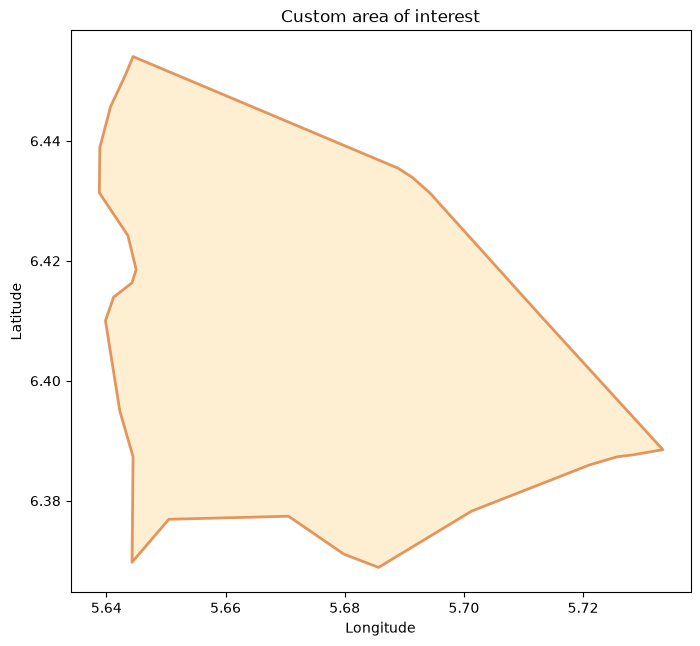

In [23]:
# Reload and visualize the saved custom AOI Shapefile.
custom_aoi_shp = load_vector_data(shapefile_path)

ax = custom_aoi_shp.plot(
    figsize=(8, 8),
    color="#FFE5B4",
    edgecolor="#D35400",
    linewidth=2,
    alpha=0.6,
)

ax.set_title("Custom area of interest")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

In [24]:
# Overlay the normalized AOI on OpenStreetMap.
custom_aoi_webmap = custom_aoi_shp.to_crs("EPSG:4326").explore(
    tiles="OpenStreetMap",
    name="Custom area of interest",
    tooltip=["id", "name"],  # type: ignore
    style_kwds={
        "fillColor": "#FFE5B4",
        "fillOpacity": 0.6,
        "color": "#D35400",
        "weight": 2,
    },
    highlight_kwds={
        "fillColor": "#FF8C00",
        "fillOpacity": 0.8,
        "weight": 3,
    },
)

custom_aoi_webmap